In [1]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.7/914.7 kB 24.9 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO  # Using YOLO for object detection

# Dataset paths
dataset_path = "/kaggle/input/moddelite/ModdeDataset"
jpeg_dataset_path = "/kaggle/working/MODDE_JPEG"
cropped_dataset_path = "/kaggle/working/MODDE_CROPPED"  # Path for cropped images

# Load YOLO model (you can use a pre-trained one like 'yolov8m.pt')
yolo_model = YOLO("yolov8m.pt")

# Function to apply bounding boxes and crop clothing items
def apply_bounding_boxes(src_dir, dest_dir):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    for root, _, files in os.walk(src_dir):
        class_name = os.path.basename(root)  # Use folder name as class label
        
        for file in files:
            src_file_path = os.path.join(root, file)
            dest_class_dir = os.path.join(dest_dir, class_name)  # Maintain class subfolders
            
            if not os.path.exists(dest_class_dir):
                os.makedirs(dest_class_dir)

            dest_file_path = os.path.join(dest_class_dir, os.path.splitext(file)[0] + ".jpg")

            try:
                print(f"Processing: {src_file_path}")  # Debugging
                img = cv2.imread(src_file_path)
                if img is None:
                    print(f"Skipping {src_file_path} - Unable to read image")
                    continue
                
                results = yolo_model(src_file_path)  # Detect clothing item
                detected_objects = len(results[0].boxes)
                print(f"Detected {detected_objects} objects in {src_file_path}")

                if detected_objects == 0:
                    continue  # Skip if no objects detected

                for result in results:
                    for box in result.boxes.xyxy:  # Get bounding box coordinates
                        x_min, y_min, x_max, y_max = map(int, box)
                        cropped = img[y_min:y_max, x_min:x_max]  # Crop clothing item
                        
                        if cropped.size == 0:
                            print(f"Skipping {src_file_path} - Empty cropped image")
                            continue
                        
                        Image.fromarray(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)).save(dest_file_path)
                        print(f"Saved cropped image to: {dest_file_path}")
                        break  # Only save the first detected clothing item
            except Exception as e:
                print(f"Failed to process {src_file_path}: {e}")

# Apply bounding boxes
apply_bounding_boxes(dataset_path, cropped_dataset_path)

# Check if cropped dataset has images
if not any(os.listdir(cropped_dataset_path)):  # Check if any class folders exist
    print(f"No images found in {cropped_dataset_path}. Check the cropping step.")
else:
    total_images = sum(len(files) for _, _, files in os.walk(cropped_dataset_path))
    print(f"Cropped dataset contains {total_images} items.")

# Ensure dataset exists before loading
if total_images > 0:
    # Load the dataset with cropped images
    data = tf.keras.utils.image_dataset_from_directory(
        cropped_dataset_path,
        labels='inferred',
        label_mode='categorical',
        batch_size=32,
        image_size=(256, 256),
        shuffle=True,
        seed=123
    )

    print("Class names:", data.class_names)

    # Optional: Print dataset summary
    for images, labels in data.take(1):
        print(f"Image batch shape: {images.shape}")
        print(f"Label batch shape: {labels.shape}")
else:
    print("No valid images found for training.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 49.7M/49.7M [00:00<00:00, 95.5MB/s]


Processing: /kaggle/input/moddelite/ModdeDataset/dress/dress (459).jpg

image 1/1 /kaggle/input/moddelite/ModdeDataset/dress/dress (459).jpg: 640x448 1 person, 999.8ms
Speed: 16.0ms preprocess, 999.8ms inference, 28.3ms postprocess per image at shape (1, 3, 640, 448)
Detected 1 objects in /kaggle/input/moddelite/ModdeDataset/dress/dress (459).jpg
Saved cropped image to: /kaggle/working/MODDE_CROPPED/dress/dress (459).jpg
Processing: /kaggle/input/moddelite/ModdeDataset/dress/dress (108).jpg

image 1/1 /kaggle/input/moddelite/ModdeDataset/dress/dress (108).jpg: 640x448 1 person, 809.5ms
Speed: 2.2ms preprocess, 809.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)
Detected 1 objects in /kaggle/input/moddelite/ModdeDataset/dress/dress (108).jpg
Saved cropped image to: /kaggle/working/MODDE_CROPPED/dress/dress (108).jpg
Processing: /kaggle/input/moddelite/ModdeDataset/dress/dress (518).jpg

image 1/1 /kaggle/input/moddelite/ModdeDataset/dress/dress (518).jpg: 640x448 1 

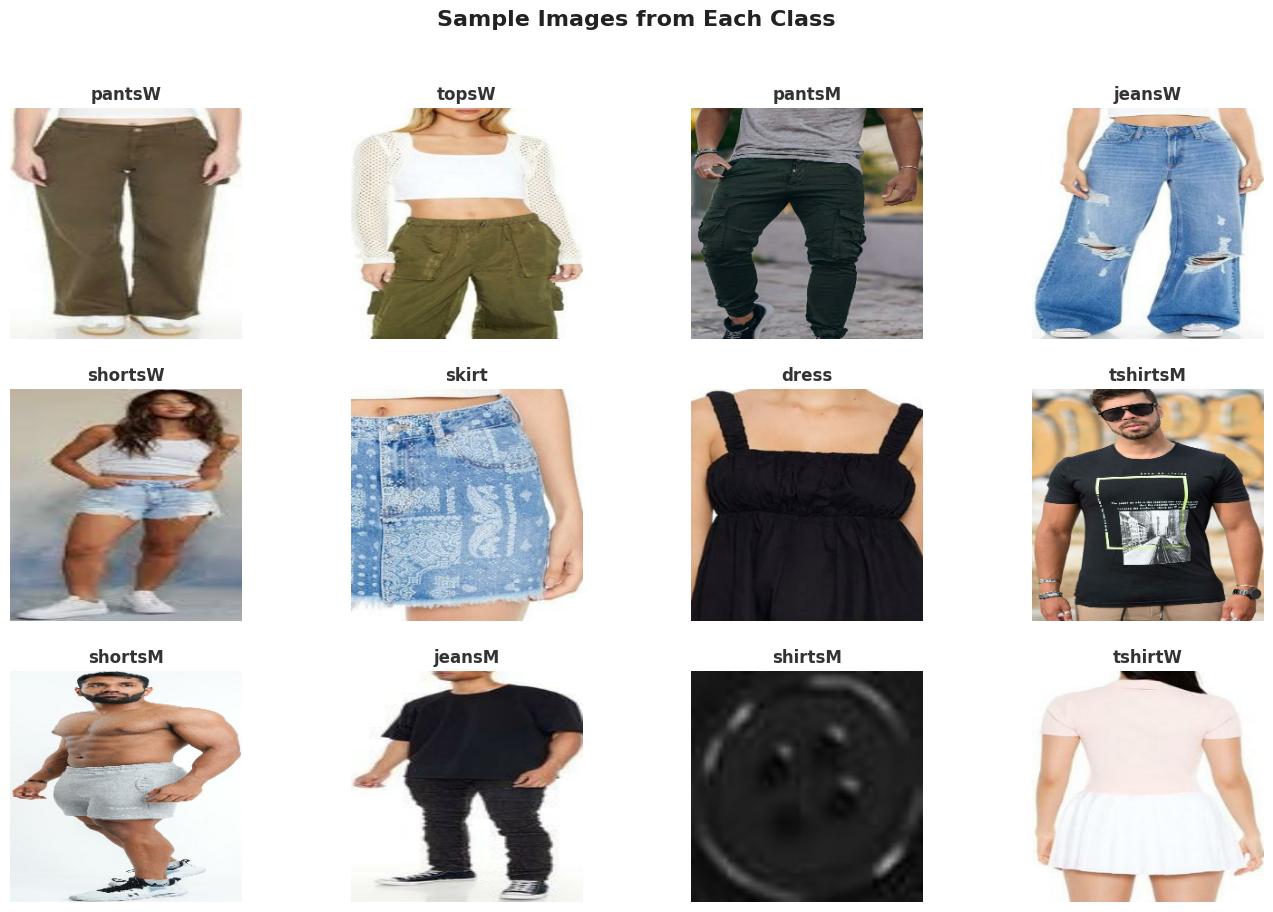

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 10))  # Adjust the figure size for better spacing
shown_classes = set()  # Track displayed classes
grid_size = (3, 4)  # Grid size: Adjust according to the number of classes

# Iterate through the dataset to display one sample per class
for images, labels in data:
    for i in range(len(images)):
        label_index = np.argmax(labels[i].numpy())  # Get the class index
        if label_index not in shown_classes:
            ax = plt.subplot(grid_size[0], grid_size[1], len(shown_classes) + 1)  # Place in grid
            ax.imshow(images[i].numpy().astype(int))
            ax.set_title(
                data.class_names[label_index], 
                fontsize=12, 
                weight="bold", 
                color="#333333"  # Modern gray tone for title
            )
            ax.axis("off")  # Remove axes for a clean look
            shown_classes.add(label_index)
        if len(shown_classes) == len(data.class_names):  # Break if all classes are displayed
            break
    if len(shown_classes) == len(data.class_names):  # Break outer loop if done
        break

# Add a central title for the whole grid
plt.suptitle(
    "Sample Images from Each Class",
    fontsize=16,
    weight="bold",
    color="#222222",
    y=0.92
)

# Adjust layout for better spacing
plt.tight_layout(pad=2.0, rect=[0, 0, 1, 0.92])
plt.show()


In [4]:
data=data.map(lambda x,y:(x/255,y)) #transformation for this pipline
data.as_numpy_iterator().next()[0].max()
# Get the total number of batches in the dataset
total_batches = len(data)

# Calculate the number of batches for training, validation, and test
train_size = int(total_batches * 0.8)
val_size = int(total_batches * 0.2)
test_size = total_batches - train_size - val_size  # Remaining for test

# Split the dataset into train, validation, and test sets
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)


CNN Architecture

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Convolutional Block 1
model.add(Conv2D(16, (3, 3), strides=1, activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D())

# Convolutional Block 2
model.add(Conv2D(32, (3, 3), strides=1, activation='relu'))
model.add(MaxPooling2D())

# Convolutional Block 3
model.add(Conv2D(16, (3, 3), strides=1, activation='relu'))
model.add(MaxPooling2D())

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))  # Slightly higher dropout in Dense layer

# Output Layer for 12 classes
model.add(Dense(12, activation="softmax"))

# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Summary of the model
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │           3,084 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,699,452 (14.11 MB)

 Trainable params: 3,699,452 (14.11 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
logdir="logs"
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir)


In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Training the model with early stopping
history = model.fit(
    train,  # Training dataset
    epochs=10,  # Number of epochs
    validation_data=val,  # Validation dataset
    callbacks=[tensorboard_callback, early_stopping]  # Added EarlyStopping
)

# Extract accuracy and loss values from training history
train_accuracy = history.history['accuracy'][-1]  # Last recorded training accuracy
val_accuracy = history.history['val_accuracy'][-1]  # Last recorded validation accuracy
train_loss = history.history['loss'][-1]  # Last recorded training loss
val_loss = history.history['val_loss'][-1]  # Last recorded validation loss

# Print training and validation accuracy separately
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.2424 - loss: 2.3903 - val_accuracy: 0.6330 - val_loss: 1.2823
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6185 - loss: 1.1850 - val_accuracy: 0.7951 - val_loss: 0.7355
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.7700 - loss: 0.7370 - val_accuracy: 0.8496 - val_loss: 0.5963
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8508 - loss: 0.4939 - val_accuracy: 0.8394 - val_loss: 0.5373
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8827 - loss: 0.3920 - val_accuracy: 0.8481 - val_loss: 0.5164
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9026 - loss: 0.2984 - val_accuracy: 0.8714 - val_loss: 0.5037
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9206 - loss: 0.2428 - val_accuracy: 0.8743 - val_loss: 0.5344
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9355 - loss: 0.2027 - val_accu

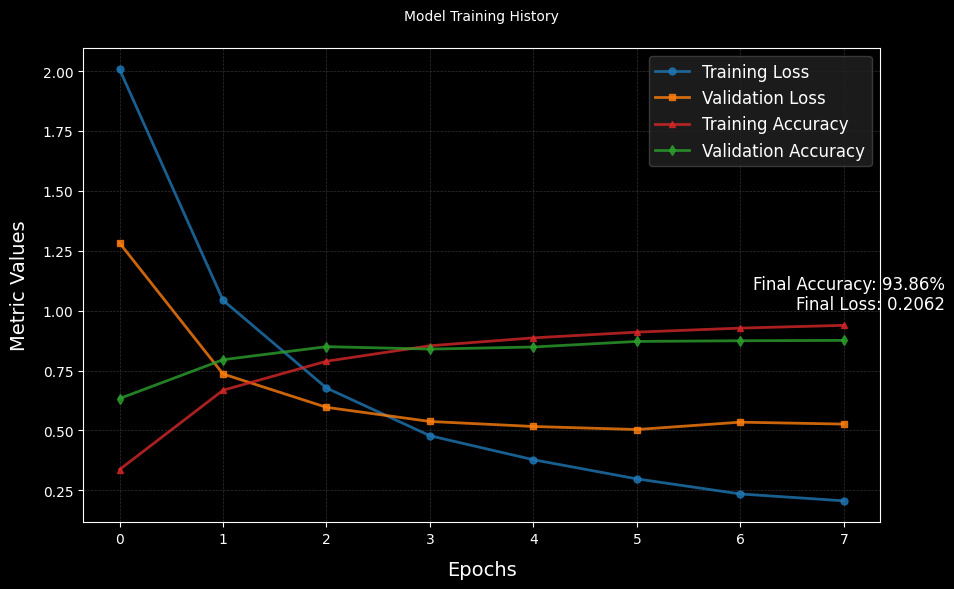

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Ensure the history object is properly used
history_dict = history.history

# Set up the dark theme
plt.style.use("dark_background")
plt.figure(figsize=(10, 6))

# Use a modern font
font_path = fm.findfont(fm.FontProperties(family="Arial"))
font_properties = fm.FontProperties(fname=font_path)

# Define colors
colors = {
    "train_loss": "#1f77b4",
    "val_loss": "#ff7f0e",
    "train_acc": "#d62728",
    "val_acc": "#2ca02c",
}

# Plot the data with markers and transparency
plt.plot(history_dict["loss"], color=colors["train_loss"], linewidth=2, alpha=0.8, marker="o", markersize=5, label="Training Loss")
plt.plot(history_dict["val_loss"], color=colors["val_loss"], linewidth=2, alpha=0.8, marker="s", markersize=5, label="Validation Loss")
plt.plot(history_dict["accuracy"], color=colors["train_acc"], linewidth=2, alpha=0.8, marker="^", markersize=5, label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], color=colors["val_acc"], linewidth=2, alpha=0.8, marker="d", markersize=5, label="Validation Accuracy")

# Add grid
plt.grid(color="#444", linestyle="--", linewidth=0.5, alpha=0.7)

# Add title and labels
plt.title("Model Training History", fontsize=16, fontproperties=font_properties, pad=20)
plt.xlabel("Epochs", fontsize=14, fontproperties=font_properties, labelpad=10)
plt.ylabel("Metric Values", fontsize=14, fontproperties=font_properties, labelpad=10)

# Add legend inside the plot
plt.legend(loc="best", fontsize=12, frameon=True, facecolor="#222", edgecolor="#444")

# Add total accuracy and loss as annotations
mod_accuracy = history_dict['accuracy'][-1]  # Accuracy from the last epoch
mod_loss = history_dict['loss'][-1]  # Loss from the last epoch
text = f"Final Accuracy: {mod_accuracy * 100:.2f}%\nFinal Loss: {mod_loss:.4f}"
plt.gcf().text(0.95, 0.5, text, fontsize=12, fontproperties=font_properties, color="white", ha="right", va="center")

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 1])

# Show the plot
plt.show()


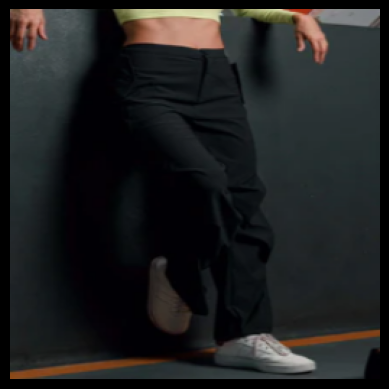

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted Class Index: 3
Found 7479 files belonging to 12 classes.
The image you provided is a: pantsM


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your trained model
# If the model is saved in the local directory, uncomment the line below:
# model = load_model('path_to_your_model')

# Load and preprocess the test image
img = cv2.imread("/kaggle/input/testing-imageskeshawa/womanPant.png")

# Check if the image loaded correctly
if img is None:
    raise ValueError("Error: Image not loaded. Check the file path.")

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image to model's expected input size (256, 256)
resized_img = cv2.resize(img, (256, 256))

# Show the image
plt.imshow(resized_img)
plt.axis('off')
plt.show()

# Normalize the image and expand dimensions to match model input
input_image = np.expand_dims(resized_img, axis=0).astype(np.float32) / 255.0

# Predict the class probabilities
yhat = model.predict(input_image)

# Get the class index with the highest probability
predicted_class = np.argmax(yhat, axis=1)[0]
print(f'Predicted Class Index: {predicted_class}')

# Load the dataset to get class names (same as during training)
jpeg_dataset_path = "/kaggle/input/moddelite/ModdeDataset"  # Replace with your dataset path
data = tf.keras.utils.image_dataset_from_directory(
    jpeg_dataset_path,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=123
)

class_names = data.class_names  # Extract class names

# Print the predicted class label
print(f'The image you provided is a: {class_names[predicted_class]}')
